In [1]:
#logistic svm knn decision tree random forest 心臟病 算出accuracy recall roc auc score 哪一個model metrics最好 

import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv('heart.csv')

In [3]:
# random forest decion tree 不用feature scaling
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:

X=df[['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']]
X=np.array(X)
y=df[['target']] 
y=np.array(y)


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0) #進行train_test_split 0.3 0.7劃分

In [6]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state=0)
RF.fit(X_train,y_train)
y_pred=RF.predict(X_test)

/var/folders/ml/hg0w_x455vj5qxkvxjndw2hc0000gn/T/ipykernel_20777/803222192.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  RF.fit(X_train,y_train)


In [7]:
from sklearn import tree

tree= tree.DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred2=tree.predict(X_test)

In [8]:
from sklearn.metrics import confusion_matrix , plot_confusion_matrix
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score
#RandomForest 表現
print('RandomForest:',recall_score(y_test,y_pred))
print('RandomForest presicion',precision_score(y_test,y_pred))
print('RandomForest f1',f1_score(y_test,y_pred))
print('RandomForest',accuracy_score(y_test,y_pred))

RandomForest: 0.9148936170212766
RandomForest presicion 0.7962962962962963
RandomForest f1 0.8514851485148516
RandomForest 0.8351648351648352


In [9]:
print('tree recall:',recall_score(y_test,y_pred2))
print('tree presicion',precision_score(y_test,y_pred2))
print('tree f1',f1_score(y_test,y_pred2))
print('tree accuracy',accuracy_score(y_test,y_pred2))

tree recall: 0.723404255319149
tree presicion 0.7391304347826086
tree f1 0.7311827956989247
tree accuracy 0.7252747252747253


In [11]:
#model loading
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
lr=LogisticRegression() 
neigh = KNeighborsClassifier(n_neighbors=3)
clf = SVC(gamma='auto')



In [12]:
#開始train data
neigh.fit(X_train,y_train) 


lr.fit(X_train,y_train);

clf.fit(X_train,y_train)

/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)
/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/s

SVC(gamma='auto')

In [13]:
y_pred3=lr.predict(X_test)#
y_pred4=neigh.predict(X_test) 
y_pred5=clf.predict(X_test)

In [14]:
from sklearn.metrics import confusion_matrix , plot_confusion_matrix
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score

In [15]:
#logistic 表現
print('logistic recall:',recall_score(y_test,y_pred3))
print('logistic presicion',precision_score(y_test,y_pred3))
print('logistic f1',f1_score(y_test,y_pred3))
print('logistic acurracy',accuracy_score(y_test,y_pred3))

logistic recall: 0.8723404255319149
logistic presicion 0.7884615384615384
logistic f1 0.8282828282828283
logistic acurracy 0.8131868131868132


In [16]:
#knn 表現
print('knn recall:',recall_score(y_test,y_pred4))
print('knn presicion',precision_score(y_test,y_pred4))
print('knn f1',f1_score(y_test,y_pred4))
print('knn acurracy',accuracy_score(y_test,y_pred4))

knn recall: 0.723404255319149
knn presicion 0.6666666666666666
knn f1 0.6938775510204082
knn acurracy 0.6703296703296703


In [17]:
#svm 表現
print('svm recall:',recall_score(y_test,y_pred5))
print('svm presicion',precision_score(y_test,y_pred5))
print('svm f1',f1_score(y_test,y_pred))
print('svm acurracy',accuracy_score(y_test,y_pred5))

svm recall: 1.0
svm presicion 0.5164835164835165
svm f1 0.8514851485148516
svm acurracy 0.5164835164835165


In [18]:
from sklearn.metrics import plot_roc_curve

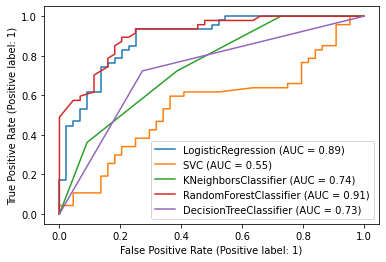

In [20]:
disp=plot_roc_curve(lr,X_test,y_test)            # plot roc curve
plot_roc_curve(clf,X_test,y_test,ax=disp.ax_);    # 
plot_roc_curve(neigh,X_test,y_test,ax=disp.ax_);
plot_roc_curve(RF,X_test,y_test,ax=disp.ax_);
plot_roc_curve(tree,X_test,y_test,ax=disp.ax_);

In [ ]:
# random forest 表現最好 AUC score=0.91